In [41]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3

In [46]:
N = 15
dataset = SyntheticDatasetV3(n=N, num_samples=(2**25), seed=42)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=2**13, shuffle=True)
def calculate_accuracy(outputs, labels):
    """
    Compute accuracy by thresholding outputs at 0.5.
    """
    predictions = (outputs < 0.5).float()
    correct = (predictions == labels).float().sum()
    return correct / labels.numel()

In [47]:
from mps import tpcp_mps
chi = 2
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"
tpcp = tpcp_mps.MPSTPCP(N = N, K = 1, d = d, enable_r=True)

In [49]:
from mps.trainer.utils import focal_loss
data, target = next(iter(dataloader))
data_flip = data.clone()
data_flip[:, 0, :] = 1 - data_flip[:, 0, :]
data = torch.cat((data, data_flip), dim=0)
target = torch.cat((target, 1 - target), dim=0)
output = tpcp(data, return_probs=True)
loss = focal_loss(output, target)
loss.backward()
# print(loss)

i = -2
g = tpcp.kraus_ops[i].grad.reshape(d**2, d**2)
u = tpcp.kraus_ops[i].reshape(d**2, d**2)
rg = u.T @ g - g.T @ u

print(rg)
# print(torch.linalg.norm(rg))
# print(u)
# # print(output[0] - output[round(len(output) / 2)])
# print(output[0])

tensor([[ 0.0000,  0.3631,  0.0043, -0.1856],
        [-0.3631,  0.0000,  0.0987,  0.0174],
        [-0.0043, -0.0987,  0.0000, -0.4047],
        [ 0.1856, -0.0174,  0.4047,  0.0000]], dtype=torch.float64,
       grad_fn=<SubBackward0>)


In [5]:
# hadamard
H = torch.tensor([[1, 1], [1, -1]], dtype=torch.float64) / np.sqrt(2)
U = torch.kron(H, H)
# tpcp.kraus_ops[-1].data[:] = U


In [6]:
x0 = torch.tensor([0, 1], dtype=torch.float64)
x1 = torch.tensor([1, 0], dtype=torch.float64)
# U = tpcp.kraus_ops[-3].reshape(d**2, d**2)
rho0 = torch.einsum("i, j->ij", x0, x0)
rho1 = torch.einsum("i, j->ij", x1, x1)
rho = torch.einsum("ij, kl->ikjl", rho0, rho1).reshape(d**2, d**2)

rho = U.T @ rho @ U

rho


tensor([[ 0.2500,  0.2500, -0.2500, -0.2500],
        [ 0.2500,  0.2500, -0.2500, -0.2500],
        [-0.2500, -0.2500,  0.2500,  0.2500],
        [-0.2500, -0.2500,  0.2500,  0.2500]], dtype=torch.float64)

In [7]:
from geoopt import optim
# from mps.unitary_optimizer import Adam
from mps.trainer.utils import focal_loss
from mps.trainer.utils import calculate_accuracy

optimizer = optim.RiemannianAdam(tpcp.kraus_ops.parameters(), lr=0.01)

for data, target in dataloader:
# for _ in range(1000):
    data, target = next(iter(dataloader))
    data_flip = data.clone()
    data_flip[:, 0, :] = 1 - data_flip[:, 0, :]
    data = torch.cat((data, data_flip), dim=0)
    target = torch.cat((target, 1 - target), dim=0)
    optimizer.zero_grad()

    outputs = tpcp(data, return_probs=True)
    loss = focal_loss(outputs, target)
    loss.backward()
    preds = outputs.argmax(dim=-1)
    acc = (preds == target).float().mean().item()
    # print(loss.item(), (outputs[0] - outputs[round(len(outputs) / 2)]).detach().numpy(), acc)
    print(loss.item(), outputs[0].detach().numpy(), acc)

    i = 0
    g = tpcp.kraus_ops[i].grad.reshape(d**2, d**2)
    u = tpcp.kraus_ops[i].reshape(d**2, d**2)
    rg = u.T @ g - g.T @ u

    # print(rg)
    # print(torch.linalg.norm(rg))

    optimizer.step()

0.37297189730751995 [0.75033012 0.24966988] 0.4990234375
0.36169158930198897 [0.50094718 0.49905282] 0.50048828125
0.3535271517143416 [0.42039074 0.57960926] 0.50244140625
0.3492162237557541 [0.51838061 0.48161939] 0.5029296875
0.3476292997890388 [0.49676016 0.50323984] 0.501953125
0.34807443886287903 [0.44202919 0.55797081] 0.49755859375
0.3494910667796106 [0.50112056 0.49887944] 0.5
0.35107756162735226 [0.39312597 0.60687403] 0.5
0.3514823593618732 [0.52285433 0.47714567] 0.5
0.351756231929808 [0.39264105 0.60735895] 0.49951171875
0.3506339277524023 [0.41284402 0.58715598] 0.5
0.34954040473878534 [0.48397084 0.51602916] 0.5
0.3481035145337888 [0.43724872 0.56275128] 0.5
0.34723918362153816 [0.53010958 0.46989042] 0.4990234375
0.3467520695552296 [0.500928 0.499072] 0.50048828125
0.3466345000584978 [0.48262439 0.51737561] 0.50244140625
0.34693885005336755 [0.51096248 0.48903752] 0.494140625
0.34741458914071766 [0.5525659 0.4474341] 0.50048828125
0.34784355560659935 [0.45857102 0.541428

KeyboardInterrupt: 

In [7]:
from geoopt import optim
from mps.unitary_optimizer import Adam

# optimizer = optim.RiemannianAdam(umps.parameters(), lr=0.0001)
optimizer = Adam(umps, lr=0.0001)

for data, target in dataloader:

    target_flip = 1 - target
    data_flip = data.clone()
    data_flip[:, 0, :] = 1 - data_flip[:, 0, :]
    target = torch.cat((target, target_flip), dim=0)
    data = torch.cat((data, data_flip), dim=0)

    optimizer.zero_grad()
    output = umps(data.permute(1, 0, 2))
    loss = focal_loss(output, target)
    loss.backward()
    optimizer.step()
    u = umps.params[0].reshape(4, 4)
    acc = calculate_accuracy(output, target)

    print("loss", loss, "acc", acc)

loss tensor([0.9370], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5010)
loss tensor([1.0235], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0190], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0262], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0189], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0238], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0201], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0259], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0220], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0101], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0169], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0252], dtype=torch.float64, grad_fn=<Di

KeyboardInterrupt: 

In [74]:
data1 = data.clone()

data1[:, 0, :] = 1 - data1[:, 0, :]

In [75]:
umps(data.permute(1, 0, 2)), umps(data1.permute(1, 0, 2))

(tensor([0.4984, 0.5552, 0.5214,  ..., 0.5059, 0.5186, 0.4657],
        dtype=torch.float64, grad_fn=<ViewBackward0>),
 tensor([0.4984, 0.5552, 0.5214,  ..., 0.5059, 0.5186, 0.4657],
        dtype=torch.float64, grad_fn=<ViewBackward0>))

In [19]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDatasetV3
from mps.simple_mps import SimpleMPS
import matplotlib.pyplot as plt

# Fixed parameters for the model
chi = 2
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"

# List of different system sizes to test
# N_list = [10, 20, 40, 80, 160, 320, 400, 500, 600, 700, 800, 900, 1000]
N_list = [10, 20, 40, 80, 160, 320, 400, ]
N_list = np.round(N_list).astype(int)
# N_list = [int(50 * (1.5 ** i for i in range(5)]
num_experiments = 100
# Batch size for data (can be adjusted as needed)
batch_size = 2**8

# Lists to store the averaged gradient statistics for each system size
avg_means = []
avg_vars = []

for N in N_list:
    print(N)
    experiment_means = []
    experiment_vars = []
    
    # Create a dataset for this system size (using a moderate number of samples)
    dataset = SyntheticDatasetV3(n=N, num_samples=2**15, seed=42)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Get one batch of data and labels
    data, target = next(iter(dataloader))
    
    # Increase the data
    data_flipped = data.clone()
    data_flipped[:, 0] = 1 - data_flipped[:, 0]  # Flip the first element in each data in the batch
    target_flipped = 1 - target  # Flip the target
    
    # Concatenate the original and flipped data and targets
    data = torch.cat((data, data_flipped), dim=0)
    target = torch.cat((target, target_flipped), dim=0)
    
    # Run several experiments to average out the gradient behavior
    for exp in range(num_experiments):
        # For each experiment, create a fresh model.
        # Here, eps is chosen as 1/N, similar to your original code.
        eps = 1 / N
        seed = np.random.randint(0, 1000000)
        smps = SimpleMPS(N, chi, d, l, layers=1, device=device, dtype=dtype, optimize=optimize, eps=eps, seed=seed)
        
        # Forward pass (note the permutation as in your code)
        output = smps(data.permute(1, 0, 2))
        
        # Compute the loss (using LogSoftmax and NLLLoss as before)
        logsoftmax = torch.nn.LogSoftmax(dim=-1)
        nnloss = torch.nn.NLLLoss(reduction="mean")
        ls = logsoftmax(output)
        loss = nnloss(ls, target)
        
        # Backward pass to compute gradients
        loss.backward()
        
        # Extract the gradient for the parameters of interest.
        # Here, we choose the parameters at index 0 and -2 (as in your snippet).
        grad_param_0 = smps.mps.params[0].grad
        grad_param_neg2 = smps.mps.params[-2].grad
        
        # Calculate mean and variance over all gradient matrix elements for both parameters.
        mean_grad_0 = grad_param_0.norm()
        var_grad_0 = grad_param_0.var().item()
        
        mean_grad_neg2 = grad_param_neg2.norm()
        var_grad_neg2 = grad_param_neg2.var().item()
        
        experiment_means.append((mean_grad_0, mean_grad_neg2))
        experiment_vars.append((var_grad_0, var_grad_neg2))
    
    # Average the gradient statistics over the experiments for this system size.
    avg_means.append((np.mean([m[0] for m in experiment_means]), np.mean([m[1] for m in experiment_means])))
    avg_vars.append((np.mean([v[0] for v in experiment_vars]), np.mean([v[1] for v in experiment_vars])))


10
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the

KeyboardInterrupt: 

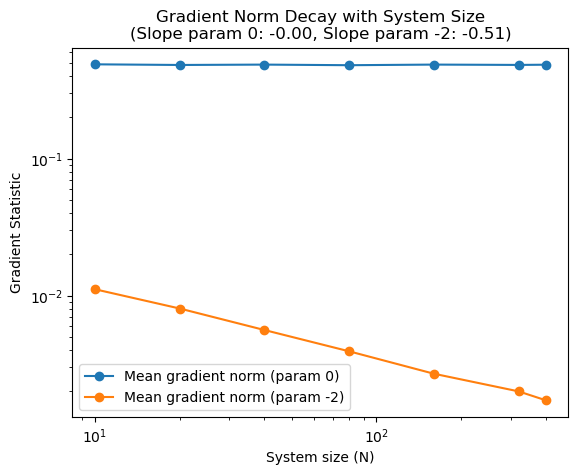

In [29]:
# Perform a linear fit on the log-log scale data for both gradients
log_N_list = np.log(N_list)
log_avg_means_0 = np.log([m[0] for m in avg_means])
log_avg_means_neg2 = np.log([m[1] for m in avg_means])
slope_0, intercept_0 = np.polyfit(log_N_list, log_avg_means_0, 1)
slope_neg2, intercept_neg2 = np.polyfit(log_N_list, log_avg_means_neg2, 1)

# Plot the mean gradient norm for both parameters vs system size in a log-log scale.
plt.figure()
plt.loglog(N_list, [m[0] for m in avg_means], marker='o', label='Mean gradient norm (param 0)')
plt.loglog(N_list, [m[1] for m in avg_means], marker='o', label='Mean gradient norm (param -2)')
plt.xlabel("System size (N)")
plt.ylabel("Gradient Statistic")
plt.title(f"Gradient Norm Decay with System Size\n(Slope param 0: {slope_0:.2f}, Slope param -2: {slope_neg2:.2f})")
plt.legend()
plt.show()

In [107]:
avg_means

[0.007832246877776823,
 0.0017804839524512553,
 0.00045537683812085544,
 0.0001284089297661758,
 3.0654468324806414e-05,
 6.498132566744372e-06,
 5.184168183931711e-06,
 2.811898510601469e-06,
 2.1091837073296406e-06,
 1.5606574421166404e-06,
 1.040615567388813e-06,
 9.279358637799916e-07,
 7.230532643596027e-07]